# Previsão de Falhas Estruturais Aplicadas no <span style="color:red;">Motor Brushless</span>

---

### Integrantes: 
- <span style="color:yellow;">Enrico Magalhães - 220950009</span>;
-  Hugo Samuel - 2023007338;
- <span style="color:brown;">Vinícius Fernandes - 210950064</span>;
- <span style="color:green;">Vitor Belo - 220950023</span>.

### Parâmetros do grupo moto-propulsor utilizado: 
(Como contexto e limitação orçamentária desse estudo, destaca-se que nenhum componente foi adquirido para o projeto. Todos os materiais, e inclusive os ensaios, estavam disponíveis e foram realizados na oficina da equipe Trem Ki Voa Micro. O uso gratuito e facilitado desses componetes foi devido à todos os integrantes do grupo serem membros atuais ou ex-integrantes da equipe).

- *Motor:* Scorpion SII-4035-450;
- *Hélice:* Master Airscrew 16×10"× 3;
- *Baterias:* LiFePO4 e LIPO;
- *ESC:* ESCTurnigy® Plush-32 120A HV?????? SERÁ?;
- *Receptor:* FrSky® V8FR-II;
-*Regulador de tensão:* Castle Creations® CCBEC10A.

### Sensores:
- *Allegro® ACS712ELCTR*;
- *Célula de carga*;
- *Arduino UNO*;

---

### Repositório no Github: https://github.com/vitorvespoli/MachineLearning_Trabalho1

---

### Definição do problema

A SAE BRASIL é uma associação dedicada ao avanço da engenharia de mobilidade no país. Uma de suas principais iniciativas é o Projeto SAE BRASIL AeroDesign, um programa educacional que desafia estudantes universitários a conceber, projetar, construir e voar aeronaves rádio-controladas, simulando os mesmos desafios enfrentados pela indústria aeronáutica.

Na 26ª Competição SAE Brasil AeroDesign, uma falha no motor impediu o voo da equipe **Trem Ki Voa Micro** (equipe de competição da UFSJ) em uma de suas tentativas oficiais. O evento foi decisivo na pontuação final, resultando na obtenção do vice-campeonato nacional por uma margem de dois pontos em relação ao primeiro colocado.

A partir disso, surgiu a necessidade de desenvolver um modelo capaz de prever falhas com base nos dados de funcionamento do sistema, evitando que falhas passem despercebidas antes de um voo oficial. Dentre as inúmeras falhas que podem interferir no sistema, para a realização desse trabalho, foram escolhidas 3 falhas principais:

- Desbalanceamento de hélice;
- Hélice quebrada;
- Rotação invertida do motor.

# Obtenção e manipulação dos dados
## Coleta de dados

A coleta de dados do grupo moto-propulsor foi feita através de ensaios em uma bancada de testes estáticos (Figura X). Essa estrutura foi desenvolvida pelo Marcelo Henrique, ex-integrante da equipe Trem Ki Voa Micro e aluno da UFSJ. Para a medição, a bancada utiliza placas Arduino conectadas a sensores que captam as variáveis do sistema: tração, corrente, tensão e RPM (Figura X). 

Para monitorar e salvar essa telemetria, utilizamos um aplicativo customizado (Figura X), também criado pelo Marcelo. Esse software nos permitiu acompanhar os parâmetros ao vivo enquanto simulávamos cada condição de voo (hélice desbalanceada, hélice quebrada e rotação invertida) e permitiu a exportação dos dados na forma de arquivos .csv. Assim, montamos a base de dados com o histórico de comportamento físico do grupo moto-propulsor. Esse conjunto de informações foi o início para aplicarmos os métodos estatísticos e treinarmos o modelo preditivo utilizando Python.

## Tratamento de dados
A utilização de uma base de dados própria visa analisar as condições operacionais e os modos de falha do projeto. Contudo, durante as simulações, as leituras dos sensores apresentaram ruídos e pequenas interferências, fatores relacionados ao uso de ligações em protoboards, à vibração estrutural gerada pela força de tração do motor e à forte turbulência do escoamento ao redor da bancada, o que torna a filtragem estatística uma etapa obrigatória para garantir a confiabilidade dos dados. 

Visando atenuar essas inconsistências nos dados, a fim de viabilizar as operações, utilizaram-se as seguintes funções:


In [ ]:
def correctDataFrame(df, columns):
    for i in range(columns):
        df[i] = df[i].astype(str).str.replace(",",".", regex=False).astype(float)
        media = df[i].mean()
        df[i] = np.where(np.abs(df[i]) > 5.5*media, media, df[i])
    return df

def statistics(df, columns):
    media = []
    median = []
    maximum = []
    minimum = []
    for i in range(columns):    
        media.append(df[i].mean())
        median.append(df[i].median())
        maximum.append(df[i].max())
        minimum.append(df[i].min())
        print(i)
    resumo = pd.DataFrame({
            "parameter": titles,
            "media": media,
            "median": median,
            "maximum": maximum,
            "minimum": minimum
        })
    print(resumo)

### Função para plotar os gráficos

In [ ]:
import matplotlib.pyplot as plt

def plot_technical(
    x,
    y,
    title="Título do Gráfico",
    xlabel="Eixo X",
    ylabel="Eixo Y",
    labels=None,
    linewidth=2.0,
    markers=None,
    figsize=(8, 5),
    grid=True,
    save=False,
    filename="grafico.png",
    dpi=300
):
    """
    Plota gráficos com estilo apropriado para relatórios técnicos.

    Parâmetros
    ----------
    x : array-like
        Vetor do eixo x.
    y : array-like ou lista de array-like
        Vetor y ou lista de vetores y para múltiplas curvas.
    title : str
        Título do gráfico.
    xlabel : str
        Rótulo do eixo x.
    ylabel : str
        Rótulo do eixo y.
    labels : list[str] ou None
        Legendas das curvas.
    linewidth : float
        Espessura das linhas.
    markers : list[str] ou None
        Marcadores para cada curva, ex: ['o', 's', '^'].
    figsize : tuple
        Tamanho da figura.
    grid : bool
        Ativa/desativa a grade.
    save : bool
        Se True, salva a figura.
    filename : str
        Nome do arquivo para salvar.
    dpi : int
        Resolução da imagem salva.
    """

    plt.figure(figsize=figsize)

    if not isinstance(y[0], (list, tuple)) and not hasattr(y[0], "__len__"):
        y = [y]

    n_curves = len(y)

    if labels is None:
        labels = [f"Curva {i+1}" for i in range(n_curves)]

    if markers is None:
        markers = [None] * n_curves

    for i in range(n_curves):
        plt.plot(
            x,
            y[i],
            label=labels[i],
            linewidth=linewidth,
            marker=markers[i]
        )

    plt.title(title, fontsize=13)
    plt.xlabel(xlabel, fontsize=11)
    plt.ylabel(ylabel, fontsize=11)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    if grid:
        plt.grid(True, linestyle='--', alpha=0.7)

    if labels is not None:
        plt.legend(fontsize=10)

    plt.tight_layout()

    if save:
        plt.savefig(filename, dpi=dpi, bbox_inches='tight')

    plt.show()

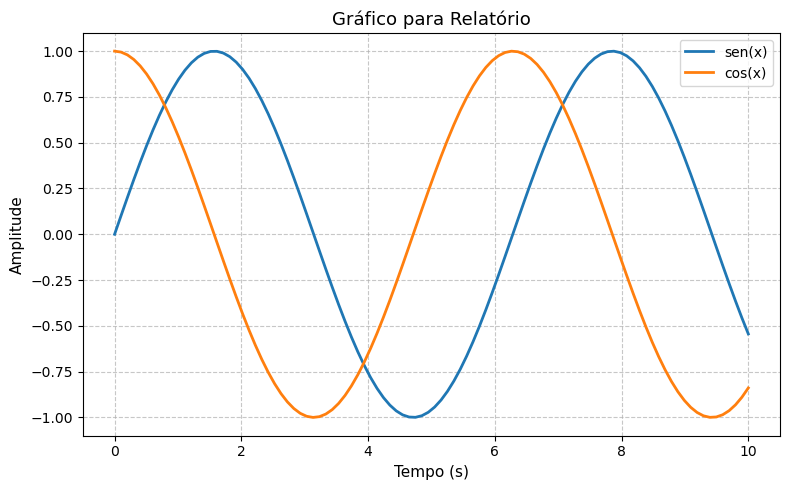

In [ ]:
import numpy as np

x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

plot_technical(
    x,
    [y1, y2],
    title="Plot Cos e Sen",
    xlabel="Tempo (s)",
    ylabel="Amplitude",
    labels=["sen(x)", "cos(x)"],
    save=True,
    filename="grafico_1.png"
)